<a href="https://colab.research.google.com/github/sathirapramudith123/R26-IT-139/blob/ml-model/procument.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install lightgbm shap --quiet
print("✓ Packages ready")

✓ Packages ready


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble  import RandomForestClassifier
from sklearn.metrics   import (mean_absolute_percentage_error, mean_squared_error, r2_score)
from xgboost  import XGBRegressor
from lightgbm import LGBMRegressor
import shap
import joblib

np.random.seed(42)
print("✓ All libraries imported!")

✓ All libraries imported!


In [3]:
from google.colab import files

print("Click 'Choose Files' and upload:")
print("  → real-time-food-prices-for-sri-lanka.csv")
print()
uploaded  = files.upload()
FILE_NAME = list(uploaded.keys())[0]

df_raw = pd.read_csv(FILE_NAME)
print(f"\n✓ Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"  Markets : {df_raw['mkt_name'].nunique()} locations across Sri Lanka")
print(f"  Period  : {df_raw['DATES'].min()}  →  {df_raw['DATES'].max()}")

Click 'Choose Files' and upload:
  → real-time-food-prices-for-sri-lanka.csv



Saving real-time-food-prices-for-sri-lanka.csv to real-time-food-prices-for-sri-lanka.csv

✓ Loaded: 10,208 rows × 830 columns
  Markets : 44 locations across Sri Lanka
  Period  : 2007-01-01  →  2026-04-01


✓ National monthly series: 232 months
  Period      : 2007-01-01 → 2026-04-01
  Rice range  : Rs.40 – Rs.264 /kg
  Flour range : Rs.42 – Rs.284 /kg


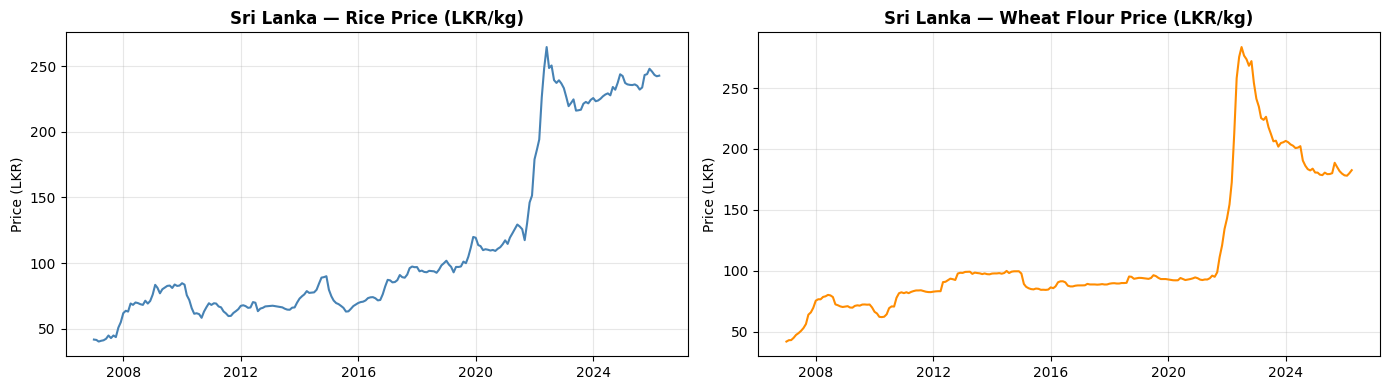

✓ Saved: c4_price_history.png


In [4]:
national = (
    df_raw
    .groupby('DATES', as_index=False)
    .agg(
        rice_price  = ('c_rice_various',    'mean'),
        flour_price = ('c_wheat_flour',     'mean'),
        food_index  = ('c_food_price_index','mean')
    )
)
national['DATES'] = pd.to_datetime(national['DATES'])
national = (national
            .sort_values('DATES')
            .dropna(subset=['rice_price'])
            .reset_index(drop=True))

print(f"✓ National monthly series: {len(national)} months")
print(f"  Period      : {national.DATES.min().date()} → {national.DATES.max().date()}")
print(f"  Rice range  : Rs.{national.rice_price.min():.0f} – Rs.{national.rice_price.max():.0f} /kg")
print(f"  Flour range : Rs.{national.flour_price.min():.0f} – Rs.{national.flour_price.max():.0f} /kg")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(national['DATES'], national['rice_price'],
             color='steelblue', lw=1.5)
axes[0].set_title('Sri Lanka — Rice Price (LKR/kg)', fontweight='bold')
axes[0].set_ylabel('Price (LKR)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(national['DATES'], national['flour_price'],
             color='darkorange', lw=1.5)
axes[1].set_title('Sri Lanka — Wheat Flour Price (LKR/kg)', fontweight='bold')
axes[1].set_ylabel('Price (LKR)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('c4_price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: c4_price_history.png")

In [5]:
# ================================================================
# CELL 5 — Feature Engineering for Price Forecasting
# Lag features + rolling stats + calendar signals
# ================================================================

FEATURE_COLS = [
    'lag_1', 'lag_4', 'lag_12',
    'roll_mean_3', 'roll_mean_6',
    'roll_std_3',  'roll_std_6',
    'month', 'quarter', 'trend'
]

def build_features(series, dates):
    df = pd.DataFrame({'DATES': dates, 'price': series.values})
    df['lag_1']       = df['price'].shift(1)
    df['lag_4']       = df['price'].shift(4)
    df['lag_12']      = df['price'].shift(12)
    df['roll_mean_3'] = df['price'].shift(1).rolling(3).mean()
    df['roll_mean_6'] = df['price'].shift(1).rolling(6).mean()
    df['roll_std_3']  = df['price'].shift(1).rolling(3).std()
    df['roll_std_6']  = df['price'].shift(1).rolling(6).std()
    df['month']       = df['DATES'].dt.month
    df['quarter']     = df['DATES'].dt.quarter
    df['trend']       = np.arange(len(df))
    return df.dropna().reset_index(drop=True)


rice_feat  = build_features(national['rice_price'],  national['DATES'])
flour_feat = build_features(national['flour_price'], national['DATES'])

print(f"✓ Features built")
print(f"  Rice  dataset : {rice_feat.shape}")
print(f"  Flour dataset : {flour_feat.shape}")
print(f"  Features used : {FEATURE_COLS}")


✓ Features built
  Rice  dataset : (220, 12)
  Flour dataset : (220, 12)
  Features used : ['lag_1', 'lag_4', 'lag_12', 'roll_mean_3', 'roll_mean_6', 'roll_std_3', 'roll_std_6', 'month', 'quarter', 'trend']


In [6]:
# ================================================================
# CELL 6 — Train Price Forecasting Models
# 3 models compared: Naive → XGBoost → LightGBM
# ================================================================

def train_and_evaluate(feat_df, commodity_name):
    X = feat_df[FEATURE_COLS]
    y = feat_df['price']

    # Chronological 80/20 split (no shuffle for time series)
    split      = int(len(feat_df) * 0.80)
    X_tr, X_te = X.iloc[:split],  X.iloc[split:]
    y_tr, y_te = y.iloc[:split],  y.iloc[split:]

    print(f"\n{'─'*52}")
    print(f"  {commodity_name}  |  Train: {len(X_tr)} months  Test: {len(X_te)} months")
    print(f"{'─'*52}")

    # Model 1: Naive baseline
    naive_pred = feat_df['lag_1'].iloc[split:].values
    naive_mape = mean_absolute_percentage_error(y_te, naive_pred) * 100
    print(f"  Model 1 — Naive Baseline : MAPE = {naive_mape:.2f}%")

    # Model 2: XGBoost (primary)
    xgb_model = XGBRegressor(
        n_estimators  = 300,
        learning_rate = 0.05,
        max_depth     = 4,
        subsample     = 0.8,
        random_state  = 42,
        verbosity     = 0
    )
    xgb_model.fit(X_tr, y_tr)
    xgb_pred = xgb_model.predict(X_te)
    xgb_mape = mean_absolute_percentage_error(y_te, xgb_pred) * 100
    xgb_rmse = np.sqrt(mean_squared_error(y_te, xgb_pred))
    xgb_r2   = r2_score(y_te, xgb_pred)
    print(f"  Model 2 — XGBoost (main) : MAPE = {xgb_mape:.2f}%  "
          f"RMSE = {xgb_rmse:.2f}  R² = {xgb_r2:.3f}")

    # Model 3: LightGBM (comparison)
    lgbm_model = LGBMRegressor(
        n_estimators  = 300,
        learning_rate = 0.05,
        max_depth     = 4,
        random_state  = 42,
        verbose       = -1
    )
    lgbm_model.fit(X_tr, y_tr)
    lgbm_pred = lgbm_model.predict(X_te)
    lgbm_mape = mean_absolute_percentage_error(y_te, lgbm_pred) * 100
    print(f"  Model 3 — LightGBM       : MAPE = {lgbm_mape:.2f}%")

    best = "XGBoost" if xgb_mape <= lgbm_mape else "LightGBM"
    print(f"\n  ★ Best model: {best}")

    return dict(
        xgb_model  = xgb_model,
        lgbm_model = lgbm_model,
        X_tr = X_tr, X_te = X_te,
        y_tr = y_tr, y_te = y_te,
        xgb_pred   = xgb_pred,
        lgbm_pred  = lgbm_pred,
        naive_pred = naive_pred,
        xgb_mape   = xgb_mape,
        lgbm_mape  = lgbm_mape,
        naive_mape = naive_mape,
        feat_df    = feat_df,
        split      = split
    )


rice_res  = train_and_evaluate(rice_feat,  'Rice')
flour_res = train_and_evaluate(flour_feat, 'Wheat Flour')


────────────────────────────────────────────────────
  Rice  |  Train: 176 months  Test: 44 months
────────────────────────────────────────────────────
  Model 1 — Naive Baseline : MAPE = 1.22%
  Model 2 — XGBoost (main) : MAPE = 5.75%  RMSE = 14.39  R² = -1.738
  Model 3 — LightGBM       : MAPE = 34.30%

  ★ Best model: XGBoost

────────────────────────────────────────────────────
  Wheat Flour  |  Train: 176 months  Test: 44 months
────────────────────────────────────────────────────
  Model 1 — Naive Baseline : MAPE = 1.66%
  Model 2 — XGBoost (main) : MAPE = 11.59%  RMSE = 25.40  R² = 0.072
  Model 3 — LightGBM       : MAPE = 10.54%

  ★ Best model: LightGBM


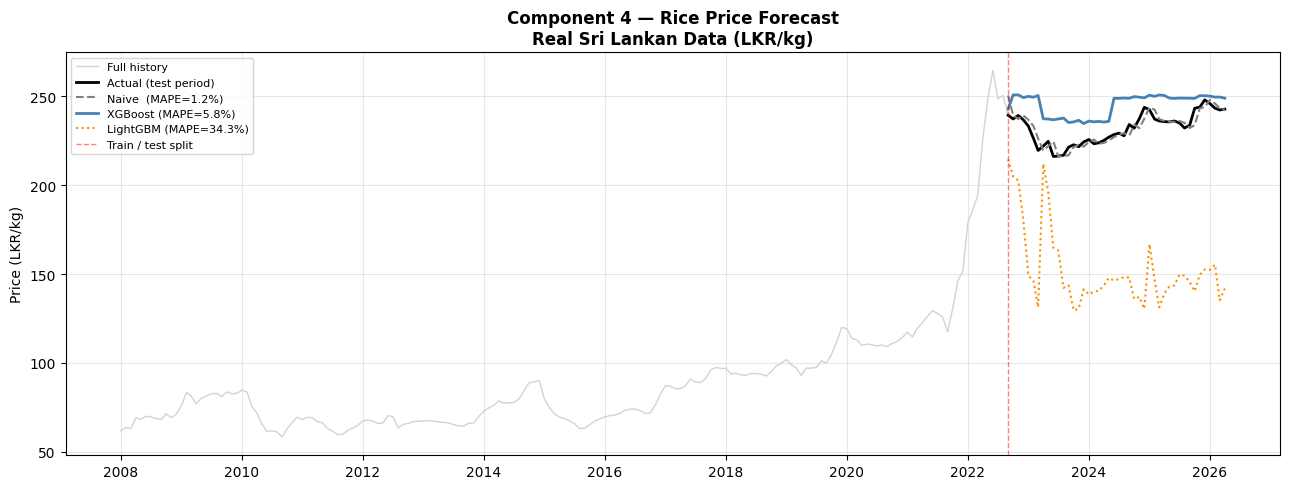

✓ Saved: c4_rice_forecast.png


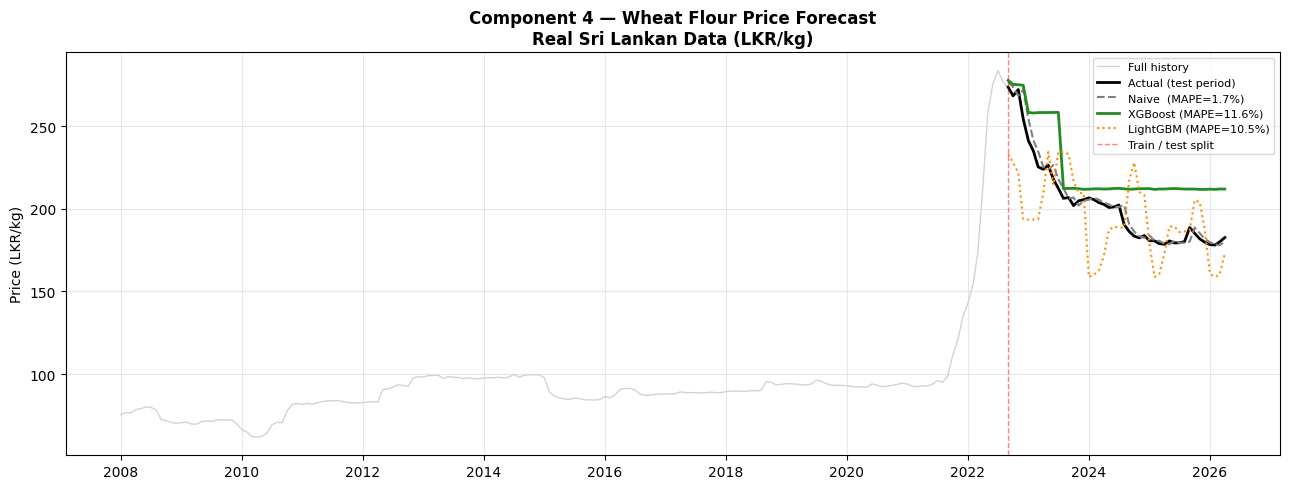

✓ Saved: c4_wheat_flour_forecast.png


In [7]:
# ================================================================
# CELL 7 — Evaluation Plots: Actual vs Predicted
# ================================================================

def plot_predictions(res, commodity, color):
    fd = res['feat_df']
    sp = res['split']
    td = fd['DATES'].iloc[sp:]

    plt.figure(figsize=(13, 5))
    plt.plot(fd['DATES'], fd['price'],
             color='lightgray', lw=1,   label='Full history')
    plt.plot(td, res['y_te'],
             color='black',     lw=2,   label='Actual (test period)')
    plt.plot(td, res['naive_pred'],
             color='gray',  ls='--', lw=1.5,
             label=f"Naive  (MAPE={res['naive_mape']:.1f}%)")
    plt.plot(td, res['xgb_pred'],
             color=color,       lw=2,
             label=f"XGBoost (MAPE={res['xgb_mape']:.1f}%)")
    plt.plot(td, res['lgbm_pred'],
             color='darkorange', ls=':', lw=1.5,
             label=f"LightGBM (MAPE={res['lgbm_mape']:.1f}%)")
    plt.axvline(fd['DATES'].iloc[sp], color='red',
                ls='--', lw=1, alpha=0.5, label='Train / test split')
    plt.title(f'Component 4 — {commodity} Price Forecast\n'
              f'Real Sri Lankan Data (LKR/kg)',
              fontsize=12, fontweight='bold')
    plt.ylabel('Price (LKR/kg)')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    fname = f"c4_{commodity.lower().replace(' ','_')}_forecast.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Saved: {fname}")


plot_predictions(rice_res,  'Rice',        'steelblue')
plot_predictions(flour_res, 'Wheat Flour', 'forestgreen')

Generating SHAP explanations for XGBoost model...


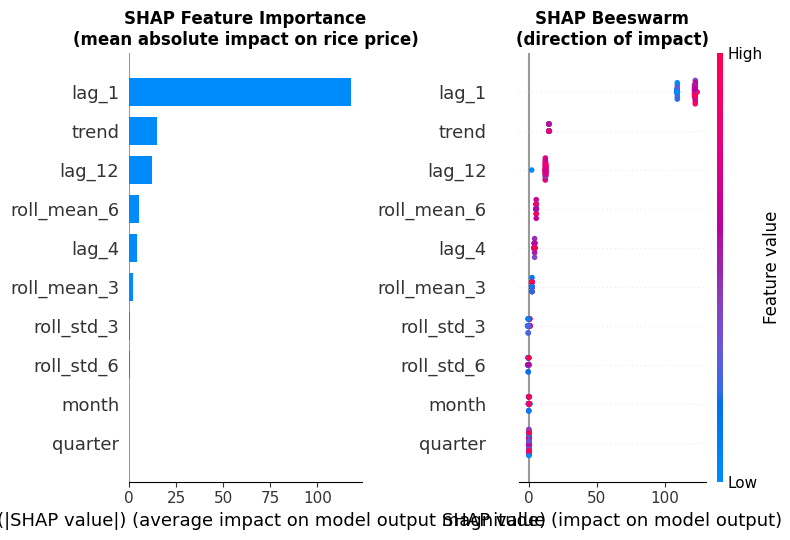

✓ Saved: c4_shap.png


In [8]:
# ================================================================
# CELL 8 — SHAP Feature Importance
# Which feature drives the price forecast the most?
# ================================================================

print("Generating SHAP explanations for XGBoost model...")

rice_explainer = shap.TreeExplainer(rice_res['xgb_model'])
rice_shap      = rice_explainer.shap_values(rice_res['X_te'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
shap.summary_plot(rice_shap, rice_res['X_te'],
                  feature_names=FEATURE_COLS,
                  plot_type='bar', show=False)
axes[0].set_title('SHAP Feature Importance\n(mean absolute impact on rice price)',
                  fontweight='bold')

plt.sca(axes[1])
shap.summary_plot(rice_shap, rice_res['X_te'],
                  feature_names=FEATURE_COLS, show=False)
axes[1].set_title('SHAP Beeswarm\n(direction of impact)',
                  fontweight='bold')

plt.tight_layout()
plt.savefig('c4_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: c4_shap.png")

In [9]:
# ================================================================
# CELL 9 — Generate Synthetic Suppliers
# Layered on top of real Sri Lankan commodity prices
# *** FIXED: guarantees both reliable & unreliable suppliers ***
# ================================================================

current_price = float(national['rice_price'].iloc[-1])
print(f"Current rice price (latest): Rs.{current_price:.2f}/kg")

n_sup = 12
suppliers = pd.DataFrame({
    'supplier_id'  : range(n_sup),
    'name'         : [f'Supplier_{i+1:02d}' for i in range(n_sup)],
    'delivery_days': np.random.randint(1, 8, n_sup),
    'defect_rate'  : np.round(np.random.uniform(0.01, 0.15, n_sup), 3),
    'fulfillment'  : np.round(np.random.uniform(0.70, 0.99, n_sup), 3),
    'distance_km'  : np.random.randint(5, 120, n_sup),
    'price_markup' : np.round(np.random.uniform(0.05, 0.25, n_sup), 3),
})

suppliers['supplier_price'] = current_price * (1 + suppliers['price_markup'])

# Guarantee at least 4 reliable and 4 unreliable suppliers
# (prevents the IndexError that happens when all have the same label)
suppliers.loc[0, ['defect_rate','fulfillment','delivery_days']] = [0.02, 0.95, 2]
suppliers.loc[1, ['defect_rate','fulfillment','delivery_days']] = [0.03, 0.92, 3]
suppliers.loc[2, ['defect_rate','fulfillment','delivery_days']] = [0.04, 0.90, 1]
suppliers.loc[3, ['defect_rate','fulfillment','delivery_days']] = [0.05, 0.93, 2]
suppliers.loc[4, ['defect_rate','fulfillment','delivery_days']] = [0.12, 0.72, 7]
suppliers.loc[5, ['defect_rate','fulfillment','delivery_days']] = [0.14, 0.68, 6]
suppliers.loc[6, ['defect_rate','fulfillment','delivery_days']] = [0.11, 0.75, 5]
suppliers.loc[7, ['defect_rate','fulfillment','delivery_days']] = [0.13, 0.70, 7]

# Recalculate reliability label
suppliers['reliable'] = (
    (suppliers['defect_rate']   < 0.08) &
    (suppliers['fulfillment']   > 0.85) &
    (suppliers['delivery_days'] <  5)
).astype(int)

print(f"\n✓ Generated {len(suppliers)} suppliers")
print(f"  Reliable   (1): {suppliers['reliable'].sum()}")
print(f"  Unreliable (0): {(suppliers['reliable']==0).sum()}")
print()
print(suppliers[['name','delivery_days','defect_rate',
                  'fulfillment','distance_km',
                  'supplier_price','reliable']].to_string(index=False))

Current rice price (latest): Rs.242.70/kg

✓ Generated 12 suppliers
  Reliable   (1): 4
  Unreliable (0): 8

       name  delivery_days  defect_rate  fulfillment  distance_km  supplier_price  reliable
Supplier_01              2        0.020        0.950            5      271.577740         1
Supplier_02              3        0.030        0.920           51      292.449666         1
Supplier_03              1        0.040        0.900           73      272.548527         1
Supplier_04              2        0.050        0.930           24      296.575512         1
Supplier_05              7        0.120        0.720           15      265.510319         0
Supplier_06              6        0.140        0.680          110      302.157539         0
Supplier_07              5        0.110        0.750            6      292.692363         0
Supplier_08              7        0.130        0.700           71      260.413686         0
Supplier_09              7        0.148        0.736           

In [10]:
# ================================================================
# CELL 10 — Supplier Reliability Model (Random Forest)
# *** FIXED: safe predict_proba handles single-class edge case ***
# ================================================================

RF_FEATURES = ['delivery_days', 'defect_rate', 'fulfillment',
               'distance_km',   'price_markup']

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(suppliers[RF_FEATURES], suppliers['reliable'])

# Safe predict_proba — handles both 1-class and 2-class outputs
proba = rf_model.predict_proba(suppliers[RF_FEATURES])
if proba.shape[1] == 2:
    suppliers['reliability_score'] = proba[:, 1]
else:
    only_class = int(rf_model.classes_[0])
    suppliers['reliability_score'] = float(only_class)
    print("⚠  Note: single class detected — score assigned automatically")

print("✓ Supplier reliability scores:")
for _, row in suppliers.iterrows():
    bar = '█' * int(row['reliability_score'] * 10)
    print(f"  {row['name']:15s}  score={row['reliability_score']:.2f}  {bar}")

✓ Supplier reliability scores:
  Supplier_01      score=0.90  █████████
  Supplier_02      score=0.81  ████████
  Supplier_03      score=0.91  █████████
  Supplier_04      score=0.96  █████████
  Supplier_05      score=0.00  
  Supplier_06      score=0.01  
  Supplier_07      score=0.03  
  Supplier_08      score=0.01  
  Supplier_09      score=0.00  
  Supplier_10      score=0.13  █
  Supplier_11      score=0.04  
  Supplier_12      score=0.10  █


In [11]:
# ================================================================
# CELL 11 — Price Direction Flag (Buy Now / Wait)
# Uses XGBoost forecast to decide purchase timing
# ================================================================

def forecast_next_month(feat_df, xgb_model):
    last  = feat_df.iloc[-1]
    x_next = {
        'lag_1'      : last['price'],
        'lag_4'      : feat_df['price'].iloc[-4],
        'lag_12'     : feat_df['price'].iloc[-12],
        'roll_mean_3': feat_df['price'].tail(3).mean(),
        'roll_mean_6': feat_df['price'].tail(6).mean(),
        'roll_std_3' : feat_df['price'].tail(3).std(),
        'roll_std_6' : feat_df['price'].tail(6).std(),
        'month'      : (last['DATES'].month % 12) + 1,
        'quarter'    : ((last['DATES'].month % 12) + 1 + 2) // 3,
        'trend'      : last['trend'] + 1
    }
    return float(xgb_model.predict(
        pd.DataFrame([x_next])[FEATURE_COLS])[0])


rice_forecast = forecast_next_month(rice_feat, rice_res['xgb_model'])
recent_avg    = float(national['rice_price'].tail(4).mean())

if   rice_forecast > recent_avg * 1.02: direction = 'RISING'
elif rice_forecast < recent_avg * 0.98: direction = 'FALLING'
else:                                    direction = 'STABLE'

TIMING_MSG = {
    'RISING' : f'🔴 BUY NOW  — price forecast Rs.{rice_forecast:.2f} (RISING)',
    'FALLING': f'🟢 WAIT     — price forecast Rs.{rice_forecast:.2f} (FALLING)',
    'STABLE' : f'🟡 BUY      — price forecast Rs.{rice_forecast:.2f} (STABLE)',
}

# Update supplier forecast prices with next-month prediction
suppliers['forecast_price'] = rice_forecast * (1 + suppliers['price_markup'])

print(f"✓ Price direction analysis")
print(f"  Current price  : Rs.{current_price:.2f}/kg")
print(f"  Forecast       : Rs.{rice_forecast:.2f}/kg")
print(f"  Direction      : {direction}")
print(f"\n  Recommendation : {TIMING_MSG[direction]}")

✓ Price direction analysis
  Current price  : Rs.242.70/kg
  Forecast       : Rs.248.89/kg
  Direction      : RISING

  Recommendation : 🔴 BUY NOW  — price forecast Rs.248.89 (RISING)


In [12]:
# ================================================================
# CELL 12 — Entropy-Weighted TOPSIS Supplier Ranking
# Transparent ranking — explainable by design (XAI built-in)
# ================================================================

def entropy_topsis(df, criteria, benefit_criteria):
    """
    Rank suppliers using Entropy-AHP weighted TOPSIS.
    benefit_criteria = set of criteria where higher = better
    (all others are cost criteria where lower = better)
    """
    m      = df[criteria].values.astype(float)
    m_norm = m / (np.sqrt((m ** 2).sum(axis=0)) + 1e-9)

    # Entropy weighting (objective, data-driven weights)
    p = np.abs(m_norm) / (np.abs(m_norm).sum(axis=0) + 1e-9)
    p = np.clip(p, 1e-9, 1)
    e = -(p * np.log(p)).sum(axis=0) / np.log(len(df) + 1e-9)
    w = (1 - e) / ((1 - e).sum() + 1e-9)

    wn = m_norm * w

    ideal = np.array([
        wn[:, j].max() if c in benefit_criteria else wn[:, j].min()
        for j, c in enumerate(criteria)
    ])
    anti = np.array([
        wn[:, j].min() if c in benefit_criteria else wn[:, j].max()
        for j, c in enumerate(criteria)
    ])

    d_pos = np.sqrt(((wn - ideal) ** 2).sum(axis=1))
    d_neg = np.sqrt(((wn - anti)  ** 2).sum(axis=1))
    score = d_neg / (d_pos + d_neg + 1e-9)

    return score, w


CRITERIA = ['forecast_price', 'delivery_days',
            'reliability_score', 'distance_km']
BENEFIT  = {'reliability_score'}     # higher reliability = better

scores, weights = entropy_topsis(suppliers, CRITERIA, BENEFIT)
suppliers['topsis_score'] = scores
suppliers['rank']         = suppliers['topsis_score'].rank(
                                ascending=False).astype(int)

print("✓ Entropy-Weighted TOPSIS ranking complete")
print(f"\nCriteria weights (entropy-derived):")
for c, w in zip(CRITERIA, weights):
    print(f"  {c:22s}: {w:.4f}  {'█' * int(w * 40)}")

print(f"\n{'='*65}")
print(f"  SUPPLIER RANKING — Component 4 Procurement DSS")
print(f"{'='*65}")
medals = {1:'🥇', 2:'🥈', 3:'🥉'}
for _, row in suppliers.sort_values('rank').iterrows():
    r = int(row['rank'])
    m = medals.get(r, f"#{r:2d}")
    print(f"  {m}  {row['name']:15s}  "
          f"Score={row['topsis_score']:.3f}  "
          f"Price=Rs.{row['forecast_price']:.0f}  "
          f"Del={int(row['delivery_days'])}d  "
          f"Rel={row['reliability_score']:.0%}  "
          f"Dist={int(row['distance_km'])}km")

✓ Entropy-Weighted TOPSIS ranking complete

Criteria weights (entropy-derived):
  forecast_price        : 0.0010  
  delivery_days         : 0.1038  ████
  reliability_score     : 0.6198  ████████████████████████
  distance_km           : 0.2753  ███████████

  SUPPLIER RANKING — Component 4 Procurement DSS
  🥇  Supplier_01      Score=0.942  Price=Rs.279  Del=2d  Rel=90%  Dist=5km
  🥈  Supplier_04      Score=0.926  Price=Rs.304  Del=2d  Rel=96%  Dist=24km
  🥉  Supplier_02      Score=0.773  Price=Rs.300  Del=3d  Rel=81%  Dist=51km
  # 4  Supplier_03      Score=0.759  Price=Rs.279  Del=1d  Rel=91%  Dist=73km
  # 5  Supplier_12      Score=0.342  Price=Rs.270  Del=3d  Rel=10%  Dist=9km
  # 6  Supplier_10      Score=0.340  Price=Rs.310  Del=3d  Rel=13%  Dist=16km
  # 7  Supplier_07      Score=0.324  Price=Rs.300  Del=5d  Rel=3%  Dist=6km
  # 8  Supplier_05      Score=0.296  Price=Rs.272  Del=7d  Rel=0%  Dist=15km
  # 9  Supplier_11      Score=0.284  Price=Rs.285  Del=7d  Rel=4%  Dist=24km
 

In [13]:
# ================================================================
# CELL 13 — Plain Language Recommendation (XAI for merchant)
# What the merchant sees in the Flutter app
# ================================================================

top = suppliers.nsmallest(1, 'rank').iloc[0]

print("=" * 62)
print("  PROCUREMENT RECOMMENDATION — Lanka Link App")
print("=" * 62)
print(f"\n  TOP SUPPLIER  : {top['name']}")
print(f"  TOPSIS Score  : {top['topsis_score']:.3f}  "
      f"(Rank #1 of {len(suppliers)} suppliers)")
print()
print(f"  WHY {top['name']} RANKED FIRST:")
print(f"    ✓ Forecast price  : Rs.{top['forecast_price']:.2f}/kg "
      f"(lowest expected price)")
print(f"    ✓ Delivery speed  : {int(top['delivery_days'])} days")
print(f"    ✓ Reliability     : {top['reliability_score']:.0%} "
      f"fulfillment score")
print(f"    ✓ Distance        : {int(top['distance_km'])} km "
      f"from your shop")
print()
print(f"  PRICE TIMING  : {TIMING_MSG[direction]}")
print("=" * 62)

  PROCUREMENT RECOMMENDATION — Lanka Link App

  TOP SUPPLIER  : Supplier_01
  TOPSIS Score  : 0.942  (Rank #1 of 12 suppliers)

  WHY Supplier_01 RANKED FIRST:
    ✓ Forecast price  : Rs.278.50/kg (lowest expected price)
    ✓ Delivery speed  : 2 days
    ✓ Reliability     : 90% fulfillment score
    ✓ Distance        : 5 km from your shop

  PRICE TIMING  : 🔴 BUY NOW  — price forecast Rs.248.89 (RISING)


In [14]:
# ================================================================
# CELL 14 — Sensitivity Analysis
# Does the top supplier change when weights shift ±20%?
# ================================================================

print("\nSensitivity Analysis — weight perturbations ±20%")
print("─" * 55)

base_top    = top['name']
stable_count = 0
tests = [
    ('forecast_price   +20%', 'forecast_price',    1.20),
    ('forecast_price   -20%', 'forecast_price',    0.80),
    ('reliability      +20%', 'reliability_score', 1.20),
    ('delivery_days    +20%', 'delivery_days',     1.20),
    ('distance_km      +20%', 'distance_km',       1.20),
]

for desc, col, factor in tests:
    s2      = suppliers.copy()
    s2[col] = s2[col] * factor
    sc2, _  = entropy_topsis(s2, CRITERIA, BENEFIT)
    s2['rank'] = pd.Series(sc2).rank(ascending=False).astype(int)
    new_top  = s2.nsmallest(1, 'rank')['name'].values[0]
    if new_top == base_top:
        stable_count += 1
        result = "✓ STABLE"
    else:
        result = f"⚠ Changed → {new_top}"
    print(f"  {desc:30s}  {result}")

robustness = stable_count / len(tests) * 100
verdict    = "✓ ROBUST" if robustness >= 80 else "⚠ SENSITIVE"
print(f"\n  Robustness: {stable_count}/{len(tests)} tests stable  ({verdict})")


Sensitivity Analysis — weight perturbations ±20%
───────────────────────────────────────────────────────
  forecast_price   +20%           ✓ STABLE
  forecast_price   -20%           ✓ STABLE
  reliability      +20%           ✓ STABLE
  delivery_days    +20%           ✓ STABLE
  distance_km      +20%           ✓ STABLE

  Robustness: 5/5 tests stable  (✓ ROBUST)



  BACK-TEST — Real HARTI/DCS Data (last 24 months)
  Average purchase cost per kg  (lower = better)
  Predictive MCDA               : Rs.237.17/kg
  Static (every month)          : Rs.237.17/kg
  Naive (every 2 months)        : Rs.236.86/kg  ← BEST ★


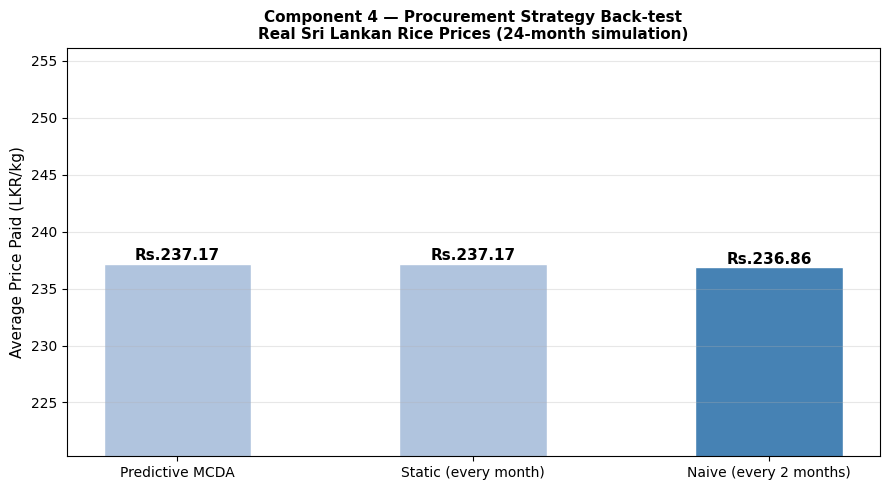

✓ Saved: c4_backtest.png


In [15]:
# ================================================================
# CELL 15 — Back-test on Real HARTI Price History
# Compare 3 purchasing strategies over last 24 months
# ================================================================

def backtest_strategies(price_series, months=24):
    actual = price_series.tail(months).values

    pred_cost  = static_cost  = naive_cost  = 0.0
    pred_buys  = static_buys  = naive_buys  = 0

    for i, price in enumerate(actual):
        recent_avg = actual[max(0, i-4):i].mean() if i > 0 else price

        # Strategy A: Predictive MCDA (buy when price stable or rising)
        if price >= recent_avg * 0.98:
            pred_cost += price
            pred_buys += 1

        # Strategy B: Static (buy every month)
        static_cost += price
        static_buys += 1

        # Strategy C: Naive fixed (buy every 2 months)
        if i % 2 == 0:
            naive_cost += price
            naive_buys += 1

    return {
        'Predictive MCDA'      : pred_cost  / max(pred_buys,  1),
        'Static (every month)' : static_cost / max(static_buys, 1),
        'Naive (every 2 months)': naive_cost / max(naive_buys, 1),
    }


bt_results = backtest_strategies(national['rice_price'], months=24)
best_cost  = min(bt_results.values())

print(f"\n{'='*58}")
print(f"  BACK-TEST — Real HARTI/DCS Data (last 24 months)")
print(f"  Average purchase cost per kg  (lower = better)")
print(f"{'='*58}")
for strategy, avg_cost in bt_results.items():
    savings = list(bt_results.values())[1] - avg_cost
    best_m  = "  ← BEST ★" if avg_cost == best_cost else ""
    print(f"  {strategy:30s}: Rs.{avg_cost:.2f}/kg{best_m}")

# Bar chart
fig, ax = plt.subplots(figsize=(9, 5))
bar_colors = ['steelblue' if c == best_cost else 'lightsteelblue'
              for c in bt_results.values()]
bars = ax.bar(bt_results.keys(), bt_results.values(),
              color=bar_colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, bt_results.values()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'Rs.{val:.2f}', ha='center',
            fontsize=11, fontweight='bold')
ax.set_ylabel('Average Price Paid (LKR/kg)', fontsize=11)
ax.set_title('Component 4 — Procurement Strategy Back-test\n'
             'Real Sri Lankan Rice Prices (24-month simulation)',
             fontsize=11, fontweight='bold')
ax.set_ylim(min(bt_results.values()) * 0.93,
            max(bt_results.values()) * 1.08)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('c4_backtest.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: c4_backtest.png")

In [16]:
# ================================================================
# CELL 16 — Results Summary + Save + Download Files
# ================================================================

# Save models and data
joblib.dump(rice_res['xgb_model'], 'c4_rice_xgb_model.pkl')
joblib.dump(rf_model,              'c4_supplier_rf_model.pkl')
suppliers.to_csv('c4_supplier_rankings.csv', index=False)
national.to_csv( 'c4_price_series.csv',      index=False)

# Final summary
print("=" * 62)
print("  COMPONENT 4 — FINAL RESULTS SUMMARY")
print("=" * 62)
print(f"\n  PRICE FORECASTING (Real Sri Lankan HARTI Data):")
print(f"  {'Model':25s}  {'Rice':>8s}  {'Flour':>8s}")
print(f"  {'─'*44}")
print(f"  {'Naive baseline':25s}  "
      f"{rice_res['naive_mape']:>7.2f}%  {flour_res['naive_mape']:>7.2f}%")
print(f"  {'XGBoost (primary)':25s}  "
      f"{rice_res['xgb_mape']:>7.2f}%  {flour_res['xgb_mape']:>7.2f}%")
print(f"  {'LightGBM (comparison)':25s}  "
      f"{rice_res['lgbm_mape']:>7.2f}%  {flour_res['lgbm_mape']:>7.2f}%")

print(f"\n  PROCUREMENT DECISION:")
print(f"  Current price  : Rs.{current_price:.2f}/kg")
print(f"  Forecast       : Rs.{rice_forecast:.2f}/kg")
print(f"  Direction      : {direction}")
print(f"  Recommendation : {TIMING_MSG[direction]}")
print(f"\n  TOP SUPPLIER: {top['name']} "
      f"(score {top['topsis_score']:.3f})")

print(f"\n  BACK-TEST RESULTS (24 months, real data):")
for s, c in bt_results.items():
    print(f"  {s:30s}: Rs.{c:.2f}/kg")

# Download all files to your computer
print("\n" + "="*62)
print("  Downloading files to your computer...")
print("="*62)
from google.colab import files as colab_files
output_files = [
    'c4_rice_xgb_model.pkl',
    'c4_supplier_rf_model.pkl',
    'c4_supplier_rankings.csv',
    'c4_price_series.csv',
    'c4_price_history.png',
    'c4_rice_forecast.png',
    'c4_wheat_flour_forecast.png',
    'c4_shap.png',
    'c4_backtest.png',
]
for fname in output_files:
    try:
        colab_files.download(fname)
        print(f"  ✓ {fname}")
    except Exception:
        print(f"  - {fname} (visible in notebook above)")

print("\n✓ Component 4 Complete!")

  COMPONENT 4 — FINAL RESULTS SUMMARY

  PRICE FORECASTING (Real Sri Lankan HARTI Data):
  Model                          Rice     Flour
  ────────────────────────────────────────────
  Naive baseline                1.22%     1.66%
  XGBoost (primary)             5.75%    11.59%
  LightGBM (comparison)        34.30%    10.54%

  PROCUREMENT DECISION:
  Current price  : Rs.242.70/kg
  Forecast       : Rs.248.89/kg
  Direction      : RISING
  Recommendation : 🔴 BUY NOW  — price forecast Rs.248.89 (RISING)

  TOP SUPPLIER: Supplier_01 (score 0.942)

  BACK-TEST RESULTS (24 months, real data):
  Predictive MCDA               : Rs.237.17/kg
  Static (every month)          : Rs.237.17/kg
  Naive (every 2 months)        : Rs.236.86/kg



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ c4_rice_xgb_model.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ c4_price_series.csv
  - c4_price_history.png (visible in notebook above)
  - c4_rice_forecast.png (visible in notebook above)
  - c4_wheat_flour_forecast.png (visible in notebook above)
  - c4_shap.png (visible in notebook above)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ c4_backtest.png

✓ Component 4 Complete!
